In [1]:
!ollama list

]11;?\NAME                ID              SIZE      MODIFIED   
gemma2:2b           8ccf136fdd52    1.6 GB    5 days ago    
llama3.1:8b         46e0c10c039e    4.9 GB    5 days ago    
qwen2.5-coder:3b    f72c60cabf62    1.9 GB    5 days ago    


### Initialize LLMs

In [2]:
from langchain_community.llms import Ollama

# Brain - LLM which will decide which tool to use
planner_llm = Ollama(model="llama3.1:8b", temperature=0.1)

# The coder
coder_llm = Ollama(model="qwen2.5-coder:3b", temperature=0.0)

/var/folders/__/t28g3nwn2vg90t4kgqdbghm40000gn/T/ipykernel_63228/3943157612.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.llms import Ollama
/var/folders/__/t28g3nwn2vg90t4kgqdbghm40000gn/T/ipykernel_63228/3943157612.py:4: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  planner_llm = Ollama(model="llama3.1:8b", temperature=0.1)


### Shared Graph Memory

In [3]:
# TypedDict - type-hinting feature that allows you to specify expected types for dictionaries
from typing import TypedDict, List

class AgentState(TypedDict):
    user_request: str # The original goal entered by the user
    plan: List[str] # the step-by-step breakdown generated by the planner
    generated_code: str # the current code written by the coder
    iterations: int # counter to prevent infinite loops
    

### Agent Nodes

In [4]:
def planner_node(state: AgentState):
    print("\n[Brain] Planner Agent is decomposing the task...")
    
    prompt = f"""You are the Master Planner. Break down the following request into a maximum of 3 sequential, logical technical steps.
    Request: {state['user_request']}
    Provide ONLY the numbered steps, nothing else."""
    
    response = planner_llm.invoke(prompt)
    
    # Update the state with the new plan steps
    steps = [step.strip() for step in response.strip().split("\n") if step]
    return {"plan": steps}


In [5]:
def coding_node(state: AgentState):
    print("\n[Engine] Coding Agent is drafting the execution script...")
    plan_str = "\n".join(state['plan'])
    prompt = f"""You are an expert developer. Write a clean, working Python script that fulfills this plan:
    {plan_str}
    
    Provide ONLY markdown wrapped code. No explanations, no introductory text."""
    
    response = coder_llm.invoke(prompt)
    
    return {
        "generated_code": response.strip(),
        "iterations": state['iterations'] + 1
    }

In [6]:
from langgraph.graph import StateGraph, END
# StateGraph - manages the flow of states and transitions (Blueprint)
# END - a special state indicating completion of the graph execution

workflow = StateGraph(AgentState)

# Register the agents as nodes
workflow.add_node("planner", planner_node)
workflow.add_node("coding", coding_node)

# Entry point of the system
workflow.set_entry_point("planner")

# planner routes directly to coder
workflow.add_edge("planner", "coding")

# ends execution
workflow.add_edge("coding", END)

app = workflow.compile()

print("LangGraph Multi-Agent network compiled!")

LangGraph Multi-Agent network compiled!


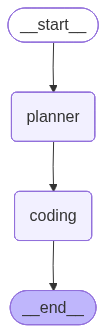

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

### Trigger Execution

In [11]:
initial_state = {
    "user_request": "Write a python script that downloads historical stock data for Apple (AAPL) using a public endpoint and prints the average closing price.",
    "plan": [],
    "generated_code": "",
    "iterations": 0
}

In [12]:
for output in app.stream(initial_state):
    for key, value in output.items():
        print(f"--- Finished executing node: {key} ---")
        
print("\nFinal generated code:\n")


[Brain] Planner Agent is decomposing the task...
--- Finished executing node: planner ---

[Engine] Coding Agent is drafting the execution script...
--- Finished executing node: coding ---

Final generated code:



In [15]:
print(output['coding']['generated_code'])

```
python
import yfinance as yf
import pandas as pd

# Define the ticker symbol
ticker_symbol = 'AAPL'

# Download historical stock data for Apple
data = yf.download(ticker_symbol)

# Calculate and print the average closing price
average_closing_price = data['Close'].mean()
print(f"The average closing price of {ticker_symbol} is: ${average_closing_price:.2f}")
```
